In [1]:
from pathlib import Path
from lerobot.datasets.lerobot_dataset import HF_LEROBOT_HOME
from lerobot.datasets.lerobot_dataset import LeRobotDataset

repo_id = "flow929/ledataset_libero_10"
root = HF_LEROBOT_HOME / repo_id

print("dataset root:", root)
print("exists:", root.exists())

for p in sorted(root.iterdir()):
    print(p.name)

ds = LeRobotDataset(repo_id)
print("len(ds) =", len(ds))
print("type(ds) =", type(ds))

/home/flow/code/mypi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataset root: /home/flow/.cache/huggingface/lerobot/flow929/ledataset_libero_10
exists: True
data
images
meta
len(ds) = 138090
type(ds) = <class 'lerobot.datasets.lerobot_dataset.LeRobotDataset'>


In [10]:
sample = ds[0]
# print(type(sample))
print(sample.keys())
sample

dict_keys(['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


{'image': tensor([[[0.7843, 0.7843, 0.7804,  ..., 0.7765, 0.7725, 0.7725],
          [0.7843, 0.7804, 0.7804,  ..., 0.7765, 0.7725, 0.7725],
          [0.7804, 0.7765, 0.7804,  ..., 0.7725, 0.7725, 0.7725],
          ...,
          [0.0784, 0.0745, 0.0667,  ..., 0.0667, 0.0667, 0.0667],
          [0.1451, 0.1412, 0.1373,  ..., 0.0314, 0.0314, 0.0314],
          [0.1804, 0.1765, 0.1725,  ..., 0.0118, 0.0118, 0.0118]],
 
         [[0.7137, 0.7137, 0.7098,  ..., 0.7098, 0.7059, 0.7059],
          [0.7137, 0.7098, 0.7098,  ..., 0.7098, 0.7059, 0.7059],
          [0.7098, 0.7059, 0.7098,  ..., 0.7059, 0.7059, 0.7059],
          ...,
          [0.0784, 0.0745, 0.0667,  ..., 0.0667, 0.0667, 0.0667],
          [0.1451, 0.1412, 0.1373,  ..., 0.0314, 0.0314, 0.0314],
          [0.1804, 0.1765, 0.1725,  ..., 0.0118, 0.0118, 0.0118]],
 
         [[0.6353, 0.6353, 0.6314,  ..., 0.6471, 0.6431, 0.6431],
          [0.6353, 0.6314, 0.6314,  ..., 0.6471, 0.6431, 0.6431],
          [0.6314, 0.6275, 0.63

In [16]:
import matplotlib.pyplot as plt
import numpy as np

sample = ds[0]

img1 = sample["image"]
img2 = sample["wrist_image"]

# 如果是 torch tensor，先转成 numpy
if hasattr(img1, "permute"):
    img1 = img1.permute(1, 2, 0).cpu().numpy()
else:
    img1 = np.transpose(img1, (1, 2, 0))

if hasattr(img2, "permute"):
    img2 = img2.permute(1, 2, 0).cpu().numpy()
else:
    img2 = np.transpose(img2, (1, 2, 0))

img1

array([[[0.78431374, 0.7137255 , 0.63529414],
        [0.78431374, 0.7137255 , 0.63529414],
        [0.78039217, 0.70980394, 0.6313726 ],
        ...,
        [0.7764706 , 0.70980394, 0.64705884],
        [0.77254903, 0.7058824 , 0.6431373 ],
        [0.77254903, 0.7058824 , 0.6431373 ]],

       [[0.78431374, 0.7137255 , 0.63529414],
        [0.78039217, 0.70980394, 0.6313726 ],
        [0.78039217, 0.70980394, 0.6313726 ],
        ...,
        [0.7764706 , 0.70980394, 0.64705884],
        [0.77254903, 0.7058824 , 0.6431373 ],
        [0.77254903, 0.7058824 , 0.6431373 ]],

       [[0.78039217, 0.70980394, 0.6313726 ],
        [0.7764706 , 0.7058824 , 0.627451  ],
        [0.78039217, 0.70980394, 0.6313726 ],
        ...,
        [0.77254903, 0.7058824 , 0.6431373 ],
        [0.77254903, 0.7058824 , 0.6431373 ],
        [0.77254903, 0.7058824 , 0.6431373 ]],

       ...,

       [[0.07843138, 0.07843138, 0.07843138],
        [0.07450981, 0.07450981, 0.07450981],
        [0.06666667, 0

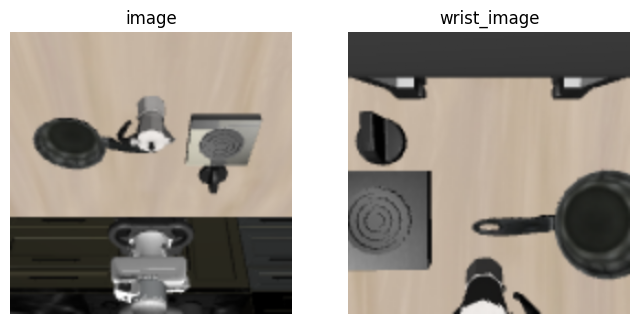

In [13]:

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("wrist_image")
plt.axis("off")

plt.show()

In [5]:
sample = ds[0]

print(type(sample))
print(sample.keys())

for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"{k:20s} shape={v.shape}, dtype={getattr(v, 'dtype', type(v))}")
    else:
        print(f"{k:20s} type={type(v)}, value={v}")

<class 'dict'>
dict_keys(['image', 'wrist_image', 'state', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])
image                shape=torch.Size([3, 256, 256]), dtype=torch.float32
wrist_image          shape=torch.Size([3, 256, 256]), dtype=torch.float32
state                shape=torch.Size([8]), dtype=torch.float32
actions              shape=torch.Size([7]), dtype=torch.float32
timestamp            shape=torch.Size([]), dtype=torch.float32
frame_index          shape=torch.Size([]), dtype=torch.int64
episode_index        shape=torch.Size([]), dtype=torch.int64
index                shape=torch.Size([]), dtype=torch.int64
task_index           shape=torch.Size([]), dtype=torch.int64
task                 type=<class 'str'>, value=KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it_demo


In [8]:
raw_sample = ds[0]

for k, v in raw_sample.items():
    if hasattr(v, "shape"):
        print(f"{k:20s} shape={tuple(v.shape)} dtype={getattr(v, 'dtype', None)}")
    else:
        print(f"{k:20s} type={type(v)} value={v}")

image                shape=(3, 256, 256) dtype=torch.float32
wrist_image          shape=(3, 256, 256) dtype=torch.float32
state                shape=(8,) dtype=torch.float32
actions              shape=(7,) dtype=torch.float32
timestamp            shape=() dtype=torch.float32
frame_index          shape=() dtype=torch.int64
episode_index        shape=() dtype=torch.int64
index                shape=() dtype=torch.int64
task_index           shape=() dtype=torch.int64
task                 type=<class 'str'> value=KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it_demo


In [9]:
sample = ds[0]

repacked = {
    "observation/image": sample["image"],
    "observation/wrist_image": sample["wrist_image"],
    "observation/state": sample["state"],
    "actions": sample["actions"],
}

if "prompt" in sample:
    repacked["prompt"] = sample["prompt"]

for k, v in repacked.items():
    if hasattr(v, "shape"):
        print(f"{k:25s} shape={tuple(v.shape)}")
    else:
        print(f"{k:25s} type={type(v)} value={v}")

observation/image         shape=(3, 256, 256)
observation/wrist_image   shape=(3, 256, 256)
observation/state         shape=(8,)
actions                   shape=(7,)


In [17]:
import numpy as np
import einops

def parse_image(image):
    image = np.asarray(image)
    if np.issubdtype(image.dtype, np.floating):
        image = (255 * image).astype(np.uint8)
    if image.shape[0] == 3:
        image = einops.rearrange(image, "c h w -> h w c")
    return image

def to_pi0_input(sample):
    out = {
        "state": sample["state"],
        "image": {
            "base_0_rgb": parse_image(sample["image"]),
            "left_wrist_0_rgb": parse_image(sample["wrist_image"]),
            "right_wrist_0_rgb": np.zeros_like(parse_image(sample["image"])),
        },
        "image_mask": {
            "base_0_rgb": True,
            "left_wrist_0_rgb": True,
            "right_wrist_0_rgb": False,
        },
    }

    if "actions" in sample:
        out["actions"] = sample["actions"]

    if "prompt" in sample:
        out["prompt"] = sample["prompt"]

    return out

In [18]:
sample = ds[0]
pi0_sample = to_pi0_input(sample)

In [19]:
sample

{'image': tensor([[[0.7843, 0.7843, 0.7804,  ..., 0.7765, 0.7725, 0.7725],
          [0.7843, 0.7804, 0.7804,  ..., 0.7765, 0.7725, 0.7725],
          [0.7804, 0.7765, 0.7804,  ..., 0.7725, 0.7725, 0.7725],
          ...,
          [0.0784, 0.0745, 0.0667,  ..., 0.0667, 0.0667, 0.0667],
          [0.1451, 0.1412, 0.1373,  ..., 0.0314, 0.0314, 0.0314],
          [0.1804, 0.1765, 0.1725,  ..., 0.0118, 0.0118, 0.0118]],
 
         [[0.7137, 0.7137, 0.7098,  ..., 0.7098, 0.7059, 0.7059],
          [0.7137, 0.7098, 0.7098,  ..., 0.7098, 0.7059, 0.7059],
          [0.7098, 0.7059, 0.7098,  ..., 0.7059, 0.7059, 0.7059],
          ...,
          [0.0784, 0.0745, 0.0667,  ..., 0.0667, 0.0667, 0.0667],
          [0.1451, 0.1412, 0.1373,  ..., 0.0314, 0.0314, 0.0314],
          [0.1804, 0.1765, 0.1725,  ..., 0.0118, 0.0118, 0.0118]],
 
         [[0.6353, 0.6353, 0.6314,  ..., 0.6471, 0.6431, 0.6431],
          [0.6353, 0.6314, 0.6314,  ..., 0.6471, 0.6431, 0.6431],
          [0.6314, 0.6275, 0.63

In [20]:
pi0_sample

{'state': tensor([-1.9947e-01, -6.3071e-03,  1.1822e+00,  3.1314e+00,  4.8670e-03,
         -2.9385e-03,  3.6224e-02, -3.6233e-02]),
 'image': {'base_0_rgb': array([[[200, 182, 162],
          [200, 182, 162],
          [199, 181, 161],
          ...,
          [198, 181, 165],
          [197, 180, 164],
          [197, 180, 164]],
  
         [[200, 182, 162],
          [199, 181, 161],
          [199, 181, 161],
          ...,
          [198, 181, 165],
          [197, 180, 164],
          [197, 180, 164]],
  
         [[199, 181, 161],
          [198, 180, 160],
          [199, 181, 161],
          ...,
          [197, 180, 164],
          [197, 180, 164],
          [197, 180, 164]],
  
         ...,
  
         [[ 20,  20,  20],
          [ 19,  19,  19],
          [ 17,  17,  17],
          ...,
          [ 17,  17,  13],
          [ 17,  17,  13],
          [ 17,  17,  13]],
  
         [[ 37,  37,  37],
          [ 36,  36,  36],
          [ 35,  35,  35],
          ...,
       

In [21]:
print("state:", pi0_sample["state"].shape, getattr(pi0_sample["state"], "dtype", type(pi0_sample["state"])))

print("base image:", pi0_sample["image"]["base_0_rgb"].shape, pi0_sample["image"]["base_0_rgb"].dtype)
print("left wrist:", pi0_sample["image"]["left_wrist_0_rgb"].shape, pi0_sample["image"]["left_wrist_0_rgb"].dtype)
print("right wrist:", pi0_sample["image"]["right_wrist_0_rgb"].shape, pi0_sample["image"]["right_wrist_0_rgb"].dtype)

print("image_mask:", pi0_sample["image_mask"])

if "actions" in pi0_sample:
    print("actions:", pi0_sample["actions"].shape, getattr(pi0_sample["actions"], "dtype", type(pi0_sample["actions"])))

if "prompt" in pi0_sample:
    print("prompt:", pi0_sample["prompt"])

state: torch.Size([8]) torch.float32
base image: (256, 256, 3) uint8
left wrist: (256, 256, 3) uint8
right wrist: (256, 256, 3) uint8
image_mask: {'base_0_rgb': True, 'left_wrist_0_rgb': True, 'right_wrist_0_rgb': False}
actions: torch.Size([7]) torch.float32
